In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [8]:
## -- V1298 Tau c
Mc1 = 4.7, 0.6 # Livingston+2026 (Earth mass)
Mc2 = 7.0, 2.0 # free-retrieval derived mass (Earth mass)
Rc = 5.08, 0.37 # Earth radii

Zc = 10.**(1.17) # metallicity
Zcerr = Zc - 10.**(1.17-0.77)
Zc = Zc, Zcerr

G_cgs = 6.6743e-8

Me_to_Mj = 0.00314558
Me_to_g = 5.974e27 
Re_to_cm = 6.378e8
masses = np.logspace(-3,1.5, 50) # in Mj
log10masses = np.log10(masses)

## -- Welbanks+2019 trend
def trendW(m):
    # m = log10(mass in jupiter masses)
    # output y = log10(H2O-based Z)
    y = -1.09 * m - 0.95 # neglects errors
    return y

## -- Sun+2024 trend
def trendS(m):
    y = -0.92*m - 0.9
    return y

In [9]:
comps = np.loadtxt('./data/V1298Tau_comparisons-values_only.csv', skiprows=1, delimiter=',', usecols=[2,3,5,6,7,8,9,10,12,13], unpack=True)
# 0=mass, 1=masserr, 2=radius, 3 = radiuserr, 4 = temp, 5 = temperr, 6 = Z, 7 = Zerr, 8 = logH2O, 9=logH2Oerr
comp_masses = comps[0]
comp_masserrs = comps[1]
comp_radii = comps[2]
comp_raderrs = comps[3]
comp_temps = comps[4]
comp_temperrs = comps[5]
comp_Z = comps[6]
comp_Zerrs = comps[7]

comp_names = np.loadtxt('./data/V1298Tau_comparisons-values_only.csv', skiprows=1, delimiter=',', usecols=[0], dtype=str, unpack=True)
Zlims = np.loadtxt('./data/V1298Tau_comparisons-values_only.csv', skiprows=1, delimiter=',', usecols=[11], dtype=str, unpack=True)


def calc_rho(M, R, Merr=0, Rerr=0):
    # M in earth mass, R in earth radius
    m_g = M*Me_to_g
    merr_g = Merr*Me_to_g
    
    r_cm = R*Re_to_cm
    rerr_cm = Rerr*Re_to_cm
    
    rho = (3.*m_g)/(4.*np.pi*pow(r_cm, 3))

    if (Merr > 0) and (Rerr > 0):
        drho1 = (9.*merr_g*merr_g) / (16.*np.pi*np.pi*pow(r_cm, 6))
        drho2 = (81.*m_g*m_g*rerr_cm*rerr_cm) / (16.*np.pi*np.pi*pow(r_cm, 8))
        rhoerr = np.sqrt(drho1 + drho2)
    else: 
        rhoerr = 0.
    return rho, rhoerr

rhoc, rhocerr = calc_rho(Mc1[0], Rc[0], Mc1[1], Rc[1])

rhoc_end, void = calc_rho(Mc1[0], 1.5, Mc1[1], Rc[1])

comp_densities = np.zeros(len(comp_masses))
comp_densityerrs = np.zeros(len(comp_masses))
for i in range(len(comp_masses)):
    comp_densities[i], comp_densityerrs[i] = calc_rho(comp_masses[i], comp_radii[i], comp_masserrs[i], comp_raderrs[i])

/tmp/ipykernel_40486/3967077405.py:17: RuntimeWarning: invalid value encountered in log10
  ax1.errorbar(comp_masses[i]*Me_to_Mj, np.log10(comp_Z[i]),  xerr=comp_masserrs[i]*Me_to_Mj, yerr=np.resize([np.log10(comp_Z[i]+comp_Zerrs[i])-np.log10(comp_Z[i]), np.log10(comp_Z[i])-np.log10(comp_Z[i]-comp_Zerrs[i])], (2,1)),


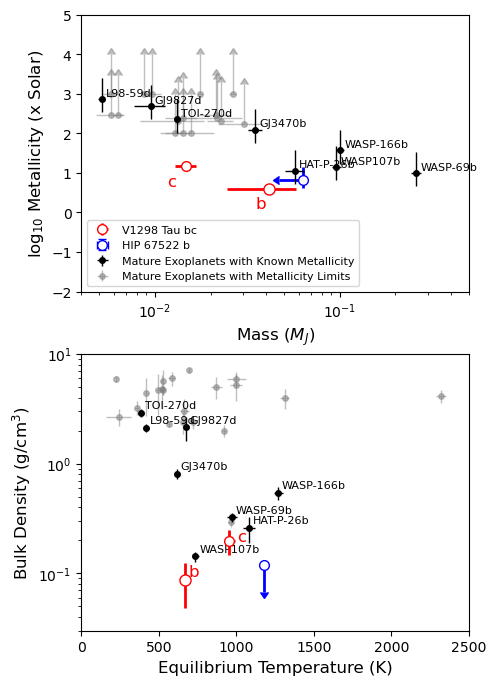

In [12]:
## DOUBLE PANEL FIGURE
fig, ax = plt.subplots(figsize=(5,8), nrows=2)
plt.subplots_adjust(hspace=0.225)
# top: Z vs mass
ax1 = ax[0]

ax1.errorbar(Mc1[0]*Me_to_Mj, np.log10(Zc[0]), yerr=0, xerr=Mc1[1]*Me_to_Mj, ls='None', elinewidth=3, zorder=9, lw=1, c='white', mfc='white', ms=8, marker='o')
ax1.errorbar(Mc1[0]*Me_to_Mj, np.log10(Zc[0]), yerr=0, xerr=Mc1[1]*Me_to_Mj, ls='None', zorder=10, elinewidth=2, lw=1, c='red', mfc='white', ms=7, marker='o', label='V1298 Tau bc')
ax1.text((Mc1[0]-1)*Me_to_Mj, np.log10(Zc[0])-0.5, 'c', c='red', fontsize=12)


for i in range(len(comp_names)):
    if i == 0:
        # skip V1298 Tau c
        continue
    if comp_names[i] == 'V1298Taub':
        ax1.errorbar(comp_masses[i]*Me_to_Mj, np.log10(comp_Z[i]),  xerr=comp_masserrs[i]*Me_to_Mj, yerr=np.resize([np.log10(comp_Z[i]+comp_Zerrs[i])-np.log10(comp_Z[i]), np.log10(comp_Z[i])-np.log10(comp_Z[i]-comp_Zerrs[i])], (2,1)),
            lw=1, ls='None', elinewidth=2, marker='o', ms=8, c='red', mfc='white') 
        ax1.text((comp_masses[i]-2)*Me_to_Mj, np.log10(comp_Z[i])-0.5, 'b', c='red', fontsize=12)
        continue
    if comp_names[i] == 'HIP67522b':
        # note that mass is upper limit
        ax1.errorbar(comp_masses[i]*Me_to_Mj, np.log10(comp_Z[i]), xerr=5*Me_to_Mj, xuplims=True, yerr=np.resize([np.log10(comp_Z[i]+comp_Zerrs[i])-np.log10(comp_Z[i]), np.log10(comp_Z[i])-np.log10(comp_Z[i]-comp_Zerrs[i])], (2,1)),
            lw=1, ls='None', elinewidth=2, marker='o', ms=7, c='blue', mfc='white', label='HIP 67522 b')
        continue
    if comp_names[i] == 'HATP26b':
        # this got messed up
        ax1.errorbar(comp_masses[i]*Me_to_Mj, np.log10(11.4), xerr=comp_masserrs[i]*Me_to_Mj, yerr=np.resize([np.log10(comp_Z[i]+comp_Zerrs[i])-np.log10(comp_Z[i]), np.log10(comp_Z[i])-np.log10(comp_Z[i]-comp_Zerrs[i])], (2,1)),
            lw=1, ls='None', elinewidth=1, marker='o', ms=4, c='black')
        ax1.text(comp_masses[i]*Me_to_Mj+0.05*(comp_masses[i]*Me_to_Mj), np.log10(comp_Z[i])+0.075, comp_names[i], fontsize=8, c='black')
        continue
    if Zlims[i] == 'N':
        ax1.errorbar(comp_masses[i]*Me_to_Mj, np.log10(comp_Z[i]), xerr=comp_masserrs[i]*Me_to_Mj, yerr=np.resize([np.log10(11.4+13.0)-np.log10(11.4), np.log10(11.4)-np.log10(11.4-8)], (2,1)),
                    lw=1, ls='None', elinewidth=1, marker='o', ms=4, zorder=2, c='black')
        ax1.text(comp_masses[i]*Me_to_Mj+0.05*(comp_masses[i]*Me_to_Mj), np.log10(comp_Z[i])+0.075, comp_names[i], fontsize=8, c='black')

    if (Zlims[i] == 'L') and (comp_Z[i] > 0):
        ax1.errorbar(comp_masses[i]*Me_to_Mj, np.log10(comp_Z[i]), xerr=comp_masserrs[i]*Me_to_Mj, yerr=1, lolims=True, lw=1, zorder=1, ls='None', marker='o', ms=4, alpha=0.5, c='gray')

ax1.errorbar(0, 0, xerr=0, yerr=0, lw=1, ls='None', elinewidth=1, marker='o', ms=4, c='black', label='Mature Exoplanets with Known Metallicity')
ax1.errorbar(0, 0, xerr=0, yerr=0, lw=1, ls='None', elinewidth=1, marker='o', ms=4, c='gray', alpha=0.5, label='Mature Exoplanets with Metallicity Limits')

ax1.set_xlim(4e-3,5e-1)
ax1.set_xscale('log')
ax1.set_xlabel(r'Mass ($M_J$)', fontsize=12)
ax1.set_ylim(-2,5)
ax1.set_ylabel(r'log$_{10}$ Metallicity (x Solar)', fontsize=12)
ax1.legend(loc='lower left', ncol=1, fontsize=8)

######################################################################################################################################
## bottom : density vs T
ax2 = ax[1]

#ax2.errorbar(comp_temps[0], comp_densities[0], xerr=comp_temperrs[0], yerr=comp_densityerrs[0], ls='None', lw=1, marker='o', ms=3, c='gray', label='Mature Exoplanets')
#ax2.errorbar(comp_temps, comp_densities, xerr=comp_temperrs, yerr=comp_densityerrs, ls='None', lw=1, marker='o', zorder=1, ms=3, c='gray')

ax2.errorbar(953, rhoc, xerr=36, yerr=rhocerr, ls='None', zorder=10, elinewidth=2, lw=1, c='red', mfc='white', ms=7, marker='o', label='V1298 Tau bc')
ax2.text(953+50, rhoc, 'c', c='red', fontsize=12)

for i in range(len(comp_names)):
    if i == 0:
        # skip V1298 Tau c
        continue
    if comp_names[i] == 'V1298Taub':
        ax2.errorbar(comp_temps[i], comp_densities[i],  xerr=comp_temperrs[i], yerr=comp_densityerrs[i], lw=1, ls='None', elinewidth=2, marker='o', ms=8, c='red', mfc='white') 
        ax2.text(comp_temps[i]+25, comp_densities[i]+(0.1*comp_densities[i]), 'b', c='red', fontsize=12)
        continue
    if comp_names[i] == 'HIP67522b':
        # note that mass is upper limit
        ax2.errorbar(comp_temps[i], comp_densities[i],  xerr=comp_temperrs[i], yerr=.05, lw=1, ls='None', uplims=True, elinewidth=2, marker='o', ms=7, c='blue', mfc='white', label='HIP 67522 b')
        continue
    if Zlims[i] == 'N':
        ax2.errorbar(comp_temps[i], comp_densities[i],  xerr=comp_temperrs[i], yerr=comp_densityerrs[i], lw=1, ls='None', elinewidth=1, zorder=4, marker='o', ms=4, c='black')
        ax2.text(comp_temps[i]+25, comp_densities[i]+(0.1*comp_densities[i]), comp_names[i], fontsize=8, c='black')
    if ((Zlims[i] == 'L') and (comp_Z[i] > 0)) or (Zlims[i] == 'Y'):
        ax2.errorbar(comp_temps[i], comp_densities[i], xerr=comp_temperrs[i], yerr=comp_densityerrs[i], lw=1, ls='None', marker='o', ms=4, zorder=1, alpha=0.5, c='gray')
        

#ax2.errorbar(0, 0, xerr=0, yerr=0, lw=1, ls='None', elinewidth=1, marker='o', ms=4, c='gray', label='Mature Exoplanets')

ax2.set_yscale('log')
ax2.set_ylabel(r'Bulk Density (g/cm$^3$)', fontsize=12)
ax2.set_xlabel(r'Equilibrium Temperature (K)', fontsize=12)
ax2.set_ylim(0.03,10)
ax2.set_xlim(0,2500)
plt.savefig('./figures/Figure9.png', dpi=600, bbox_inches='tight')
plt.show()